
# Global Bike Retailer — Profitability & Customer Analytics

**Author:** *Data Analytics Portfolio*  ·  **Dataset:** [Sales Data (Kaggle)](https://www.kaggle.com/datasets/serhatabuk/sales-data-csv)  ·  **113,036 transactions · 2011–2016 · 6 countries**

---

## Executive summary

This notebook analyses ~113k bike-store transactions for a multinational retailer selling **Bikes, Accessories and Clothing** across six countries. The goal is to answer a single strategic question:

> **Revenue and profit do not come from the same place — so where should the business actually focus?**

**Headline findings**

1. **Bikes are the revenue engine, Accessories are the margin engine.** Bikes generate **~72% of revenue** at a **~33% margin**, while Accessories sell for a fraction of the ticket size but at a **~59% margin**. The strategic lever is **attach-rate / cross-sell**, not just selling more bikes.
2. **Profit is highly concentrated.** A small set of products and two countries (United States + Australia) carry a disproportionate share of profit — a classic Pareto structure.
3. **Discounting is shallow but uneven.** Realised prices sit on average **~9.6% below list**, and the deepest discounts land on the *lowest-margin* bikes — a margin-erosion watch-point.
4. **The calendar is not trustworthy for trend analysis.** A forensic audit (Section 1) shows the year dimension is *templated* (2011≡2012, 2013≡2015, 2014≡2016) with 2014 & 2016 truncated at July. We therefore treat the data as a **cross-section** and study seasonality only as a **pooled month-of-year shape** — never as year-over-year growth.

> ⚠️ **Analyst's note on integrity.** Rather than present fabricated YoY growth (which this dataset would happily produce), Section 1 documents exactly *why* the time axis is unreliable and scopes the rest of the analysis to questions the data genuinely supports. Good analysis is as much about what you *refuse* to claim as what you show.


## 0 · Setup

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import calendar

# --- locate project root (works whether run from /notebooks or repo root) ---
ROOT = Path.cwd()
while not (ROOT / "sales_data.csv").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import data_prep as dp
import viz

FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- visual identity ---
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#cdd6db", "axes.labelcolor": viz.INK,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": viz.INK,
    "axes.labelsize": 11, "xtick.color": viz.INK, "ytick.color": viz.INK,
    "text.color": viz.INK, "font.size": 11, "axes.grid": True,
    "grid.color": "#eef2f4", "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110,
})

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=144, bbox_inches="tight", facecolor="white")

from matplotlib.lines import Line2D
def category_legend(ax, cats=("Bikes", "Accessories", "Clothing"), loc="best", title="Category"):
    # fixed-size legend markers (bubble charts otherwise inherit the huge s= sizes)
    handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=viz.CATEGORY_COLORS[c],
                      markeredgecolor="white", markersize=11, label=c) for c in cats]
    ax.legend(handles=handles, title=title, frameon=False, loc=loc, fontsize=9)

pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.2 | numpy 2.4.2



---
## 1 · Data forensics & quality audit

Before any analysis, we interrogate the raw file. Every cleaning decision below is **evidence-based** and reproduced from `src/data_prep.py` so the notebook, the Streamlit app and the README all share one source of truth.


In [2]:
raw = dp.load_raw()
print(f"Raw shape: {raw.shape[0]:,} rows x {raw.shape[1]} columns")
raw.head()

Raw shape: 113,036 rows x 18 columns


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,2013-11-26,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,2015-11-26,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,2014-03-23,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,2016-03-23,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,2014-05-15,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [3]:
report = dp.audit(raw)
audit_tbl = pd.DataFrame(
    [(k, v) for k, v in report.items() if not isinstance(v, dict)],
    columns=["check", "value"],
)
audit_tbl

,check,value
0,n_rows,113036
1,n_cols,18
2,date_min,2011-01-01
3,date_max,2016-07-31
4,null_cells,0
5,exact_duplicate_rows,1000
6,identity_revenue_eq_cost_plus_profit,1.00
7,identity_cost_eq_unitcost_x_qty,1.00
8,identity_revenue_eq_listprice_x_qty,0.06
9,calendar_columns_consistent,True



### 1.1 · The accounting identities hold — the money columns are internally consistent

| Identity | Holds for |
|---|---|
| `Revenue = Cost + Profit` | **100%** of rows |
| `Cost = Unit_Cost × Order_Quantity` | **100%** of rows |
| `Revenue = Unit_Price × Order_Quantity` | only **5.8%** of rows |

The first two identities are perfect, so `Revenue`, `Cost` and `Profit` are trustworthy. The third *fails* by design: **`Unit_Price` behaves like a list/catalog price, while `Revenue` is what was actually booked** — and booked revenue is *always ≤* list value. That gap is a genuine, analysable feature: an **implied discount** (Section 6).


In [4]:
# Quantify the list-vs-realized gap
gap = raw["Unit_Price"] * raw["Order_Quantity"] - raw["Revenue"]
print(f"Rows where Revenue  < list value : {(gap > 0).mean():6.1%}")
print(f"Rows where Revenue == list value : {(gap == 0).mean():6.1%}")
print(f"Rows where Revenue  > list value : {(gap < 0).mean():6.1%}  <- never happens")

Rows where Revenue  < list value :  94.2%
Rows where Revenue == list value :   5.8%
Rows where Revenue  > list value :   0.0%  <- never happens



### 1.2 · The calendar is templated — *the smoking gun*

If we lay out **order counts by year × month**, three things jump out:

1. **2014 and 2016 stop in July** — the entire second half of those years is empty.
2. The monthly *shape* of **2013 is identical to 2015**, and **2014 is identical to 2016**, and **2011 is identical to 2012**.

Real businesses do not produce byte-identical monthly volumes two years apart. This is a **synthetically expanded calendar**, which means **year-over-year growth here is an artifact, not a signal.**


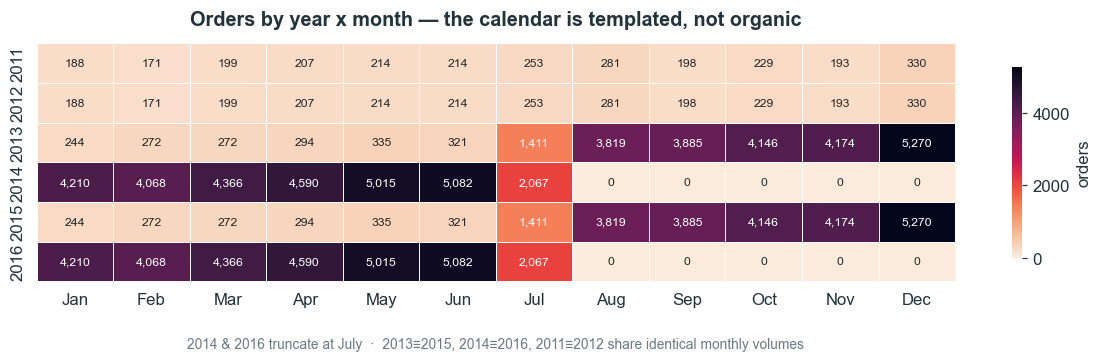

In [5]:
rc = (raw.assign(_m=pd.to_datetime(raw["Date"]).dt.month)
         .pivot_table(index="Year", columns="_m", values="Revenue",
                      aggfunc="size", fill_value=0)
         .sort_index())
rc.columns = [calendar.month_abbr[m] for m in rc.columns]

fig, ax = plt.subplots(figsize=(11, 3.6))
sns.heatmap(rc, cmap="rocket_r", annot=True, fmt=",d", annot_kws={"size": 8},
            linewidths=.6, linecolor="white",
            cbar_kws={"label": "orders", "shrink": .8}, ax=ax)
ax.set_title("Orders by year x month — the calendar is templated, not organic", pad=12)
ax.set_xlabel(""); ax.set_ylabel("")
ax.text(0.5, -0.28,
        "2014 & 2016 truncate at July  ·  2013≡2015, 2014≡2016, 2011≡2012 share identical monthly volumes",
        transform=ax.transAxes, ha="center", fontsize=9, color="#6b7b83")
plt.tight_layout()
save_fig(fig, "01_calendar_forensics")
plt.show()

In [6]:
# Prove the 'twin years' numerically
twins = report["templated_year_twins"]
for k, v in twins.items():
    a, _, b = k.split("_")
    print(f"  monthly order-count vector  {a} == {b} : {v}")
print("\nMonths populated per year:", report["months_populated_per_year"])

  monthly order-count vector  2011 == 2012 : True
  monthly order-count vector  2013 == 2015 : True
  monthly order-count vector  2014 == 2016 : True

Months populated per year: {2011: 12, 2012: 12, 2013: 12, 2014: 7, 2015: 12, 2016: 7}



### 1.3 · Duplicates: exactly 1,000 byte-identical rows

The duplicate count is **exactly 1,000** — a suspiciously round number for organic data, and there is **no order id** that would let us treat true repeat purchases as distinct. We treat them as an injected artifact and drop them.


In [7]:
print(f"Exact duplicate rows: {raw.duplicated().sum():,}")
raw[raw.duplicated(keep=False)].sort_values(list(raw.columns)).head(4)

Exact duplicate rows: 1,000


,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
69018,2011-02-20,20,February,2011,25,Young Adults (25-34),F,Canada,British Columbia,Bikes,Road Bikes,"Road-250 Red, 52",1,1519,2443,900,1519,2419
69019,2011-02-20,20,February,2011,25,Young Adults (25-34),F,Canada,British Columbia,Bikes,Road Bikes,"Road-250 Red, 52",1,1519,2443,900,1519,2419
58238,2011-03-03,3,March,2011,43,Adults (35-64),F,United States,California,Bikes,Road Bikes,"Road-150 Red, 44",1,2171,3578,1335,2171,3506
58239,2011-03-03,3,March,2011,43,Adults (35-64),F,United States,California,Bikes,Road Bikes,"Road-150 Red, 44",1,2171,3578,1335,2171,3506



### 1.4 · Cleaning decisions (all reproduced in `src/data_prep.py`)

| # | Issue | Decision |
|---|---|---|
| 1 | 1,000 exact duplicate rows | **Drop** (injected artifact, no order id) |
| 2 | `Day` / `Month` / `Year` duplicate `Date` (100% consistent) | Keep `Date` as the single source of truth; re-derive calendar features |
| 3 | `Seniors (64+)` label overlaps `Adults (35-64)` cosmetically | Relabel **`Seniors (65+)`** (actual min age in bucket is 65) |
| 4 | Templated / partial-year calendar | **Scope out YoY trends**; analyse as cross-section + pooled month-of-year |

**Not removed:** 58 loss-making orders (negative profit) are *real* loss-leader sales and are kept for the discount analysis.


In [8]:
df = dp.load_data(save_clean=True)   # raw -> clean -> features, writes data/sales_clean.csv
print(f"Clean & feature-engineered frame: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Removed {len(raw) - len(df):,} duplicate rows")
print("\nEngineered features:")
df[["Revenue","Profit","Profit_Margin","List_Revenue","Discount_Amount",
    "Discount_Pct","Realized_Unit_Price","Month_Name","Weekday","Quarter"]].head()

Clean & feature-engineered frame: 112,036 rows x 27 columns
Removed 1,000 duplicate rows

Engineered features:


,Revenue,Profit,Profit_Margin,List_Revenue,Discount_Amount,Discount_Pct,Realized_Unit_Price,Month_Name,Weekday,Quarter
0,950,590,0.62,960,10,0.01,118.75,November,Tuesday,4
1,950,590,0.62,960,10,0.01,118.75,November,Thursday,4
2,2401,1366,0.57,2760,359,0.13,104.39,March,Sunday,1
3,2088,1188,0.57,2400,312,0.13,104.40,March,Wednesday,1
4,418,238,0.57,480,62,0.13,104.50,May,Thursday,2



---
## 2 · Executive KPIs


In [9]:
k = dp.kpi_summary(df)
kpi_rows = [
    ("Total revenue",        viz.money(k["total_revenue"])),
    ("Total profit",         viz.money(k["total_profit"])),
    ("Gross margin",         viz.pct(k["gross_margin_pct"])),
    ("Orders",               f"{k['n_orders']:,}"),
    ("Units sold",           f"{k['units_sold']:,}"),
    ("Avg order value",      viz.money(k["avg_order_value"], 2)),
    ("Avg profit / order",   viz.money(k["avg_order_profit"], 2)),
    ("Avg discount vs list", viz.pct(k["avg_discount_pct"])),
    ("Discount given ($)",   viz.money(k["discount_dollars"])),
    ("Countries",            f"{k['n_countries']}"),
    ("Distinct products",    f"{k['n_products']}"),
    ("Loss-making orders",   f"{k['loss_making_orders']}"),
]
pd.DataFrame(kpi_rows, columns=["KPI", "Value"])

,KPI,Value
0,Total revenue,"$84,826,772"
1,Total profit,"$32,046,239"
2,Gross margin,37.8%
3,Orders,"112,036"
4,Units sold,"1,333,705"
5,Avg order value,$757.14
6,Avg profit / order,$286.04
7,Avg discount vs list,9.6%
8,Discount given ($),"$9,861,816"
9,Countries,6



---
## 3 · Product & category profitability — the backbone

This is the core of the story: **where revenue comes from is not where profit comes from.**


In [10]:
econ = dp.category_economics(df)
econ.round({"Revenue":0,"Profit":0,"Margin_%":1,"Revenue_Share_%":1,
            "Profit_Share_%":1,"Avg_Order_Value":0})

,Revenue,Profit,Orders,Units,Margin_%,Revenue_Share_%,Profit_Share_%,Avg_Order_Value
Product_Category,,,,,,,,
Bikes,61434484,20399726,25794,36201,33.20,72.40,63.70,"2,382.00"
Accessories,15022766,8807194,69312,1042791,58.60,17.70,27.50,217.00
Clothing,8369522,2839319,16930,254713,33.90,9.90,8.90,494.00


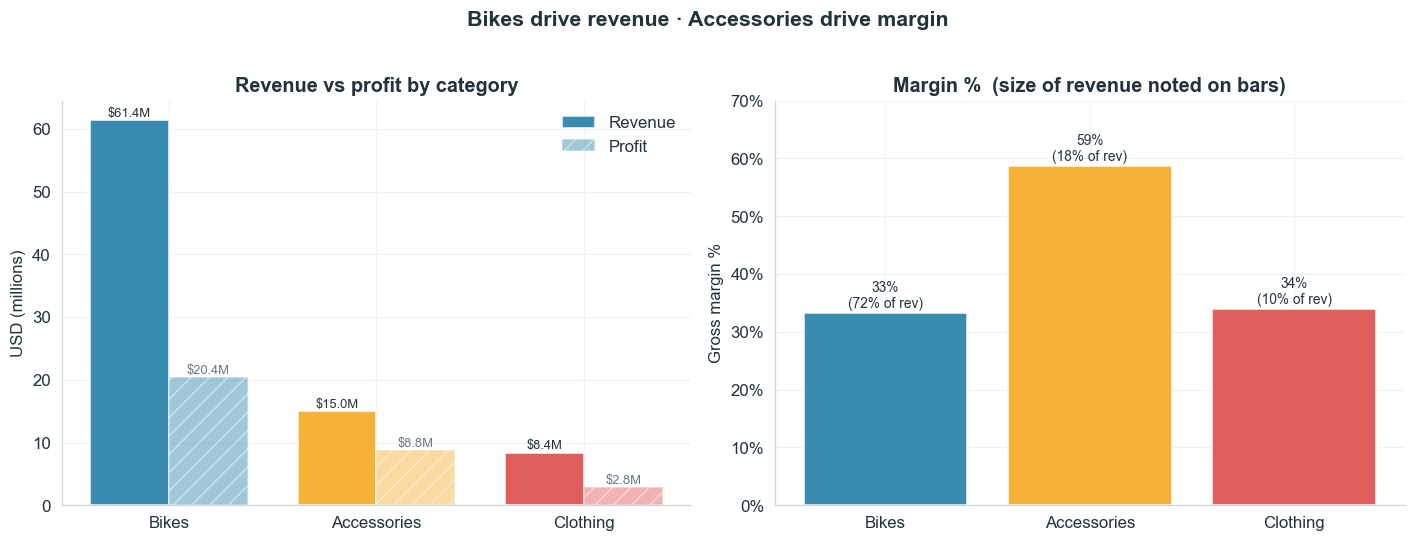

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
cats = econ.index.tolist()
colors = [viz.CATEGORY_COLORS[c] for c in cats]

# Left: revenue vs profit ($M)
ax = axes[0]
x = np.arange(len(cats)); w = 0.38
ax.bar(x - w/2, econ["Revenue"]/1e6, w, label="Revenue", color=colors, alpha=.95)
ax.bar(x + w/2, econ["Profit"]/1e6, w, label="Profit",  color=colors, alpha=.45,
       hatch="//", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel("USD (millions)")
ax.set_title("Revenue vs profit by category")
for i, c in enumerate(cats):
    ax.text(i - w/2, econ["Revenue"].iloc[i]/1e6 + .6, viz.money_compact(econ["Revenue"].iloc[i]),
            ha="center", fontsize=8.5, color=viz.INK)
    ax.text(i + w/2, econ["Profit"].iloc[i]/1e6 + .6, viz.money_compact(econ["Profit"].iloc[i]),
            ha="center", fontsize=8.5, color="#6b7b83")
ax.legend(frameon=False)

# Right: margin % with revenue-share annotation
ax = axes[1]
bars = ax.bar(cats, econ["Margin_%"], color=colors, alpha=.95)
ax.set_ylabel("Gross margin %")
ax.set_title("Margin %  (size of revenue noted on bars)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for i, c in enumerate(cats):
    ax.text(i, econ["Margin_%"].iloc[i] + 1,
            f"{econ['Margin_%'].iloc[i]:.0f}%\n({econ['Revenue_Share_%'].iloc[i]:.0f}% of rev)",
            ha="center", fontsize=9, color=viz.INK)
ax.set_ylim(0, 70)
fig.suptitle("Bikes drive revenue · Accessories drive margin", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig(fig, "02_category_profitability")
plt.show()


### 3.1 · The volume-vs-margin trade-off (sub-category map)

Each bubble is a sub-category. **Right = bigger basket (higher avg order value), up = higher margin, bubble area = total revenue.** The two engines of the business sit in opposite corners: high-ticket / low-margin Bikes on the right, low-ticket / high-margin Accessories on the left.


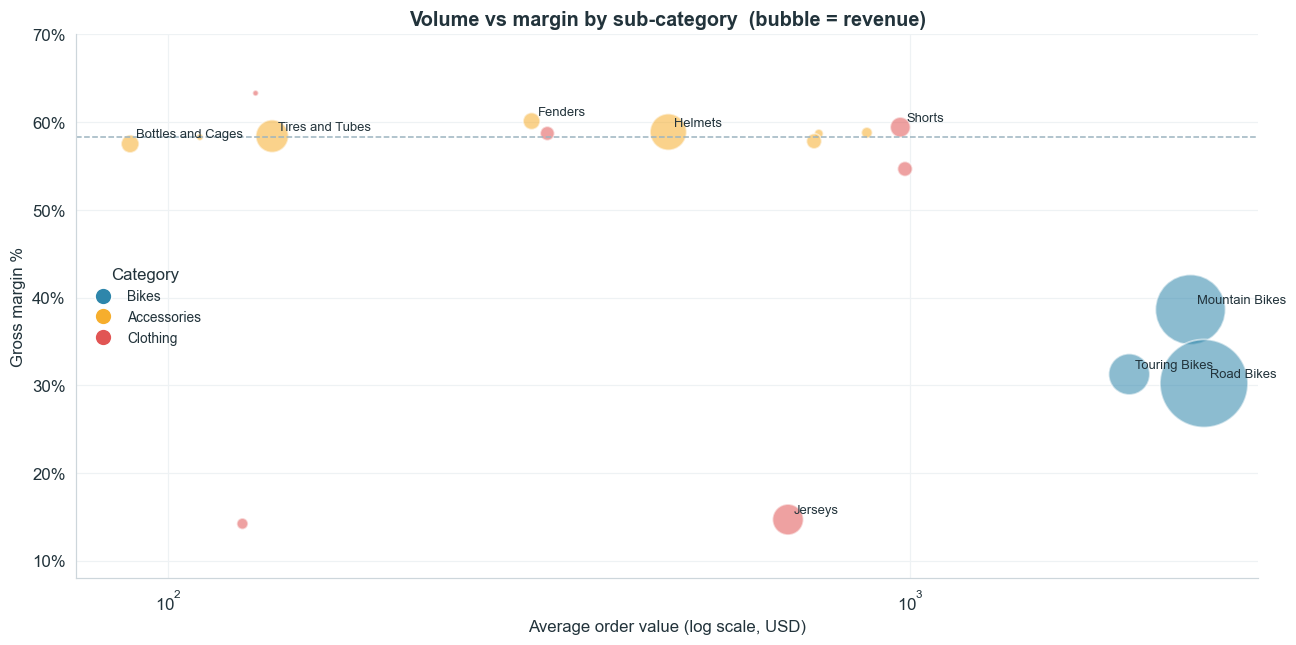

In [12]:
sub = (df.groupby(["Product_Category", "Sub_Category"], observed=True)
         .agg(Revenue=("Revenue","sum"), Profit=("Profit","sum"), Orders=("Revenue","size"))
         .reset_index())
sub["Margin"] = sub["Profit"] / sub["Revenue"] * 100
sub["AOV"] = sub["Revenue"] / sub["Orders"]

fig, ax = plt.subplots(figsize=(12, 6))
for cat, g in sub.groupby("Product_Category"):
    ax.scatter(g["AOV"], g["Margin"], s=g["Revenue"]/1e4,
               color=viz.CATEGORY_COLORS[cat], alpha=.55, edgecolor="white",
               linewidth=1.2, label=cat)
ax.set_xscale("log")
ax.set_xlabel("Average order value (log scale, USD)")
ax.set_ylabel("Gross margin %")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.axhline(sub["Margin"].median(), color="#9DB4C0", ls="--", lw=1)
ax.set_title("Volume vs margin by sub-category  (bubble = revenue)")
# annotate the notable bubbles
for _, r in sub.sort_values("Revenue", ascending=False).head(9).iterrows():
    ax.annotate(r["Sub_Category"], (r["AOV"], r["Margin"]),
                fontsize=8.5, xytext=(4, 4), textcoords="offset points", color=viz.INK)
ax.set_ylim(8, 70)
category_legend(ax, loc="center left")
plt.tight_layout()
save_fig(fig, "03_volume_margin_quadrant")
plt.show()


### 3.2 · Profit is concentrated — Pareto of products


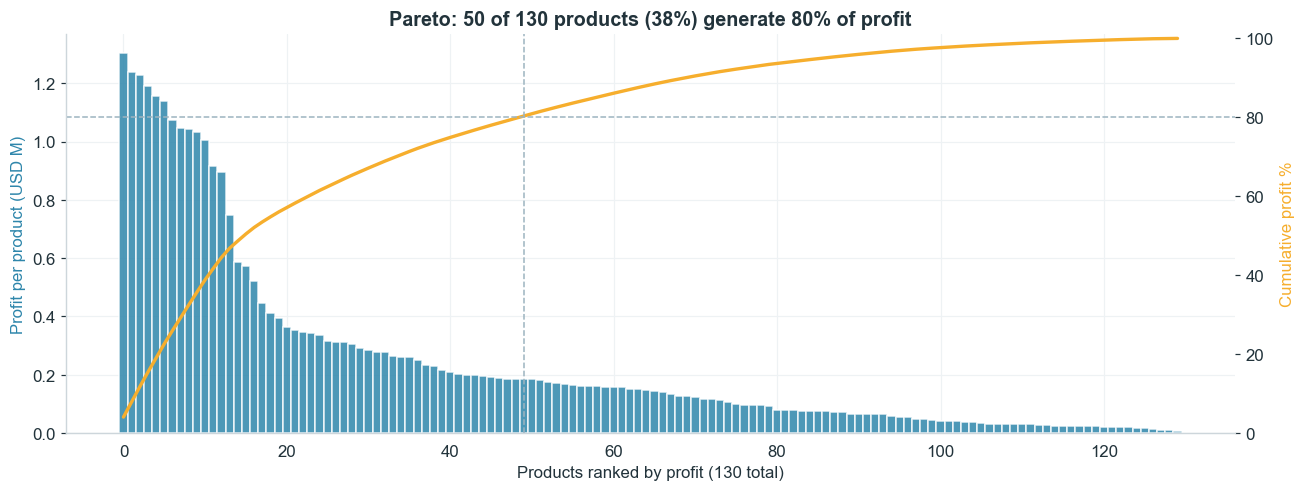

,Product_Category,Product,Revenue,Profit,Orders,Margin_%
0,Bikes,"Mountain-200 Black, 38",3345501,1302237,1199,38.90
1,Bikes,"Road-150 Red, 62",3810023,1237388,814,32.50
2,Bikes,"Mountain-200 Silver, 42",3070174,1226878,1050,40.00
3,Accessories,"Sport-100 Helmet, Red",2018651,1191175,4218,59.00
4,Bikes,"Mountain-200 Silver, 38",3011267,1155311,1097,38.40
5,Accessories,"Sport-100 Helmet, Black",1947731,1140795,4148,58.60
6,Bikes,"Mountain-200 Black, 46",2756837,1075401,986,39.00
7,Accessories,"Sport-100 Helmet, Blue",1773816,1047701,3786,59.10
8,Bikes,"Road-150 Red, 52",3152610,1044569,702,33.10
9,Bikes,"Mountain-200 Black, 42",2630865,1032061,921,39.20


In [13]:
prod = (df.groupby("Product")["Profit"].sum().sort_values(ascending=False))
cum = prod.cumsum() / prod.sum() * 100
n_for_80 = int((cum <= 80).sum()) + 1

fig, ax = plt.subplots(figsize=(12, 4.6))
ax.bar(range(len(prod)), prod.values/1e6, color=viz.ACCENT, alpha=.85, width=1.0)
ax.set_ylabel("Profit per product (USD M)", color=viz.ACCENT)
ax.set_xlabel("Products ranked by profit (130 total)")
ax2 = ax.twinx()
ax2.plot(range(len(prod)), cum.values, color=viz.ACCENT_2, lw=2.2)
ax2.axhline(80, color="#9DB4C0", ls="--", lw=1)
ax2.axvline(n_for_80 - 1, color="#9DB4C0", ls="--", lw=1)
ax2.set_ylabel("Cumulative profit %", color=viz.ACCENT_2)
ax2.set_ylim(0, 101); ax2.grid(False)
ax.set_title(f"Pareto: {n_for_80} of 130 products ({n_for_80/130:.0%}) generate 80% of profit")
plt.tight_layout()
save_fig(fig, "04_product_pareto")
plt.show()

top10 = (df.groupby(["Product_Category","Product"])
           .agg(Revenue=("Revenue","sum"), Profit=("Profit","sum"), Orders=("Revenue","size"))
           .sort_values("Profit", ascending=False).head(10).reset_index())
top10["Margin_%"] = (top10["Profit"]/top10["Revenue"]*100).round(1)
top10.round({"Revenue":0,"Profit":0})


---
## 4 · Customer demographics

> **Caveat:** there is no customer id in this dataset, so behavioural analytics (RFM, CLV, repeat-purchase, cohorts, market-basket) are **not possible**. Demographics are analysed at the *transaction* level — i.e. *attributes of purchases*, not unique people.


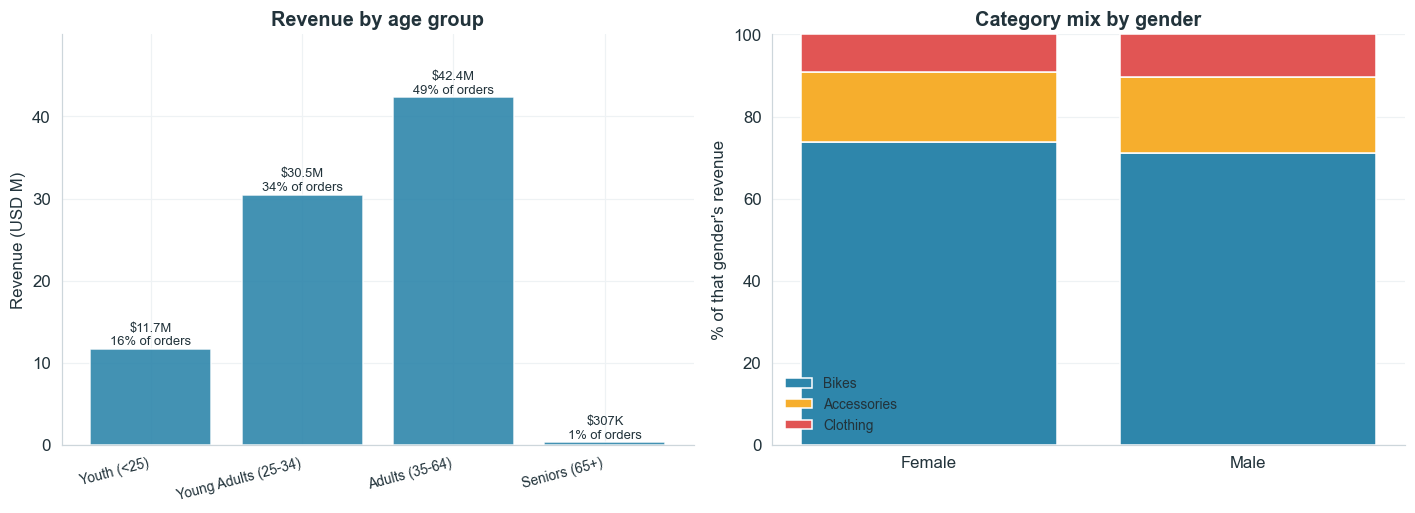

Margin by age group (%):
Age_Group
Youth (<25)            37.30
Young Adults (25-34)   37.10
Adults (35-64)         38.30
Seniors (65+)          44.80


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Age group: revenue + margin
ag = (df.groupby("Age_Group", observed=True)
        .agg(Revenue=("Revenue","sum"), Profit=("Profit","sum"), Orders=("Revenue","size")))
ag["Margin"] = ag["Profit"]/ag["Revenue"]*100
ax = axes[0]
ax.bar(range(len(ag)), ag["Revenue"]/1e6, color=viz.ACCENT, alpha=.9)
ax.set_xticks(range(len(ag))); ax.set_xticklabels(ag.index, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("Revenue (USD M)")
ax.set_title("Revenue by age group")
ax.set_ylim(0, ag["Revenue"].max()/1e6 * 1.18)
for i in range(len(ag)):
    ax.text(i, ag["Revenue"].iloc[i]/1e6+.5,
            f"{viz.money_compact(ag['Revenue'].iloc[i])}\n{ag['Orders'].iloc[i]/len(df):.0%} of orders",
            ha="center", fontsize=8.5)

# Gender: revenue split + category preference
gd = (df.groupby(["Customer_Gender","Product_Category"], observed=True)["Revenue"].sum()
        .unstack().fillna(0))
gd_share = gd.div(gd.sum(axis=1), axis=0) * 100
ax = axes[1]
bottom = np.zeros(len(gd_share))
for cat in ["Bikes","Accessories","Clothing"]:
    ax.bar(gd_share.index, gd_share[cat], bottom=bottom,
           color=viz.CATEGORY_COLORS[cat], label=cat)
    bottom += gd_share[cat].values
ax.set_ylabel("% of that gender's revenue")
ax.set_title("Category mix by gender")
ax.set_ylim(0, 100); ax.legend(frameon=False, fontsize=9)
ax.set_xticks(range(len(gd_share))); ax.set_xticklabels(["Female","Male"])
plt.tight_layout()
save_fig(fig, "05_demographics")
plt.show()

print("Margin by age group (%):")
print(ag["Margin"].round(1).to_string())


---
## 5 · Geographic performance


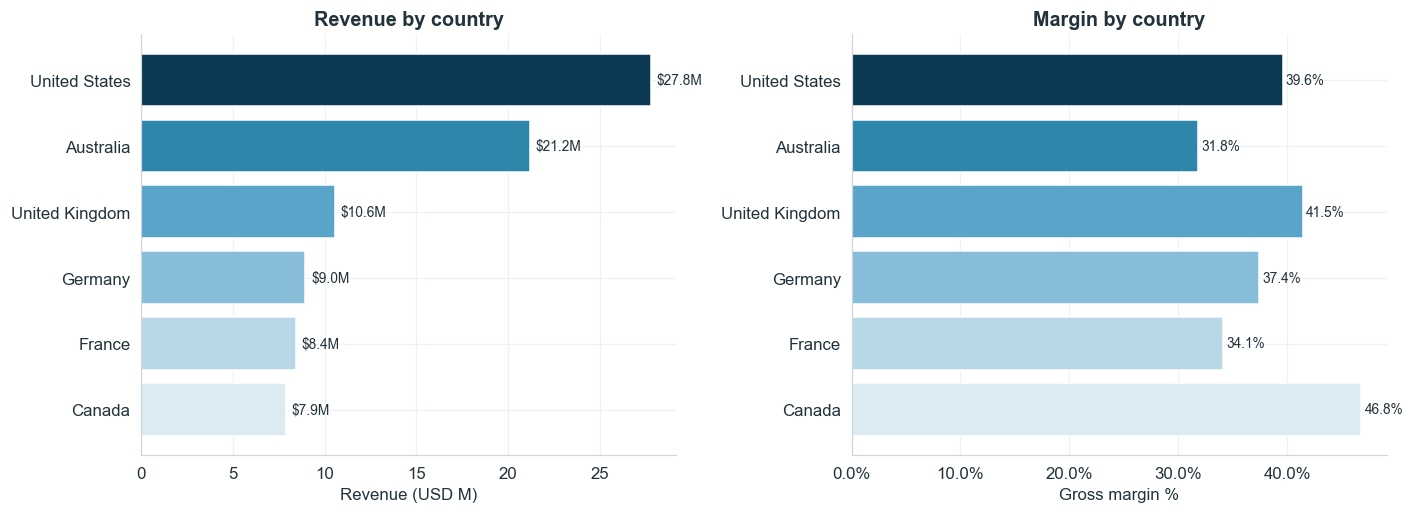

,Revenue,Profit,Orders,Margin
Country,,,,
United States,27777098,10997638,38840,39.60
Australia,21196395,6740522,23736,31.80
United Kingdom,10575628,4383987,13486,41.50
Germany,8956724,3349991,11027,37.40
France,8414745,2872082,10920,34.10
Canada,7906182,3702019,14027,46.80


In [15]:
ctry = (df.groupby("Country")
          .agg(Revenue=("Revenue","sum"), Profit=("Profit","sum"), Orders=("Revenue","size")))
ctry["Margin"] = ctry["Profit"]/ctry["Revenue"]*100
ctry = ctry.sort_values("Revenue", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
ax = axes[0]
order = ctry.index.tolist()
ax.barh(order, ctry["Revenue"]/1e6, color=viz.SEQ6[:len(order)])
ax.invert_yaxis()
ax.set_xlabel("Revenue (USD M)")
ax.set_title("Revenue by country")
for i, c in enumerate(order):
    ax.text(ctry["Revenue"].iloc[i]/1e6 + .3, i, viz.money_compact(ctry["Revenue"].iloc[i]),
            va="center", fontsize=9)

ax = axes[1]
ax.barh(order, ctry["Margin"], color=viz.SEQ6[:len(order)])
ax.invert_yaxis()
ax.set_xlabel("Gross margin %")
ax.set_title("Margin by country")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
for i, c in enumerate(order):
    ax.text(ctry["Margin"].iloc[i] + .3, i, f"{ctry['Margin'].iloc[i]:.1f}%", va="center", fontsize=9)
plt.tight_layout()
save_fig(fig, "06_geography_country")
plt.show()
ctry.round({"Revenue":0,"Profit":0,"Margin":1})

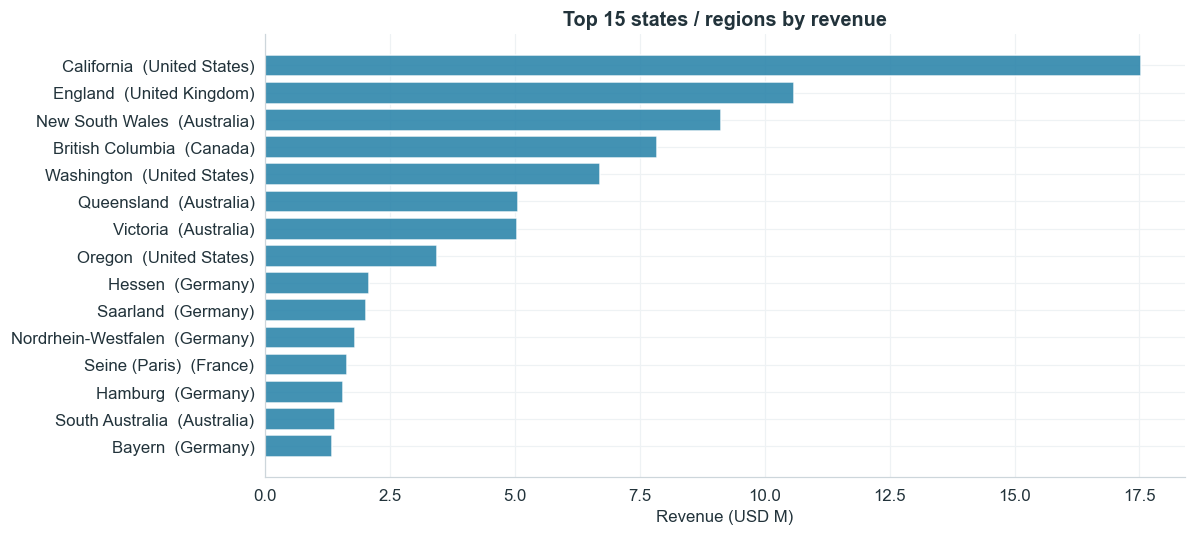

In [16]:
# Top states
st = (df.groupby(["Country","State"])["Revenue"].sum()
        .sort_values(ascending=False).head(15)[::-1])
fig, ax = plt.subplots(figsize=(11, 5))
labels = [f"{s}  ({c})" for c, s in st.index]
ax.barh(labels, st.values/1e6, color=viz.ACCENT, alpha=.9)
ax.set_xlabel("Revenue (USD M)")
ax.set_title("Top 15 states / regions by revenue")
plt.tight_layout()
save_fig(fig, "07_geography_states")
plt.show()


---
## 6 · Price realisation & discount analysis

Recall from Section 1: booked `Revenue` sits *below* the `Unit_Price` list value. We treat that gap as an **implied discount** and ask: **is discounting disciplined, or are we cutting price hardest on the products we can least afford to?**


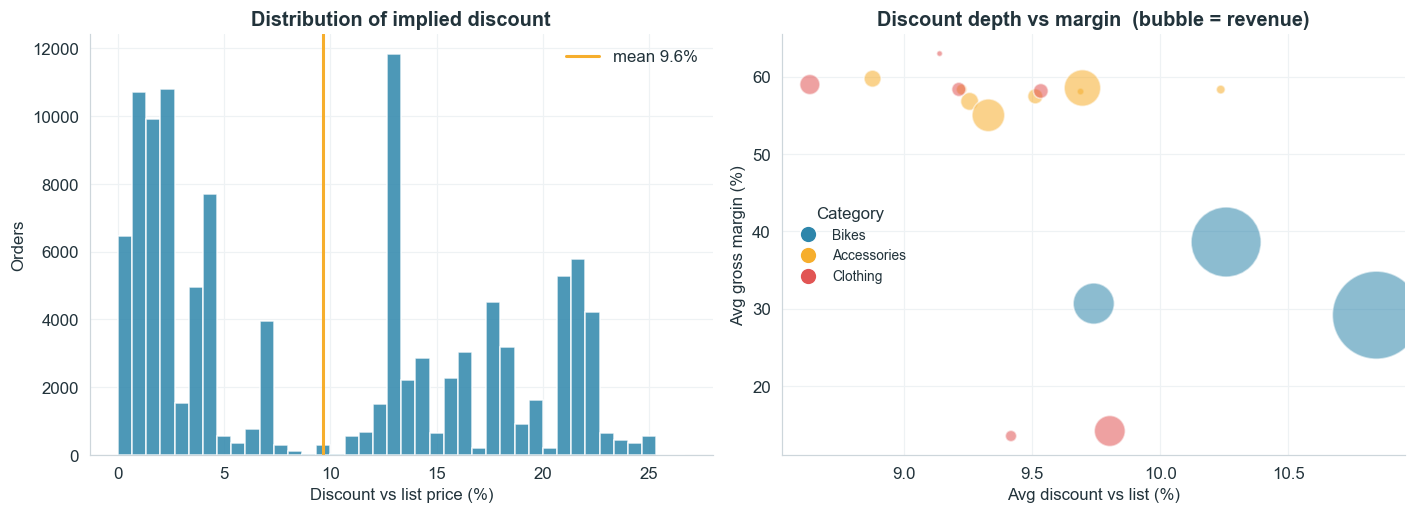

Avg discount by category:
Product_Category
Accessories    9.37
Bikes         10.49
Clothing       9.43


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax = axes[0]
ax.hist(df["Discount_Pct"]*100, bins=40, color=viz.ACCENT, alpha=.85)
ax.axvline(df["Discount_Pct"].mean()*100, color=viz.ACCENT_2, lw=2,
           label=f"mean {df['Discount_Pct'].mean()*100:.1f}%")
ax.set_xlabel("Discount vs list price (%)")
ax.set_ylabel("Orders")
ax.set_title("Distribution of implied discount")
ax.legend(frameon=False)

# discount depth vs margin by sub-category (does discount erode margin?)
sd = (df.groupby(["Product_Category","Sub_Category"], observed=True)
        .agg(Discount=("Discount_Pct","mean"), Margin=("Profit_Margin","mean"),
             Revenue=("Revenue","sum")).reset_index())
ax = axes[1]
for cat, g in sd.groupby("Product_Category"):
    ax.scatter(g["Discount"]*100, g["Margin"]*100, s=g["Revenue"]/1e4,
               color=viz.CATEGORY_COLORS[cat], alpha=.55, edgecolor="white",
               linewidth=1.1, label=cat)
ax.set_xlabel("Avg discount vs list (%)")
ax.set_ylabel("Avg gross margin (%)")
ax.set_title("Discount depth vs margin  (bubble = revenue)")
category_legend(ax, loc="center left")
plt.tight_layout()
save_fig(fig, "08_discount_analysis")
plt.show()

print("Avg discount by category:")
print((df.groupby("Product_Category")["Discount_Pct"].mean()*100).round(2).to_string())


---
## 7 · Seasonality (robust, pooled month-of-year)

Because the calendar is templated and 2014/2016 are truncated at July, we **cannot** read year-over-year trends. We *can* recover an indicative **month-of-year seasonal shape** by averaging each month's revenue **across only the years in which that month is populated** — this removes the Jan–Jul truncation bias.

> The Q4 holiday lift (peak in December) is plausible. Read the **July dip with caution**, though: it is partly an artifact of the templated H1/H2 split (2013≡2015 ramp up in the second half, while 2014≡2016 are front-loaded), so the curve is best treated as *indicative* rather than precise.


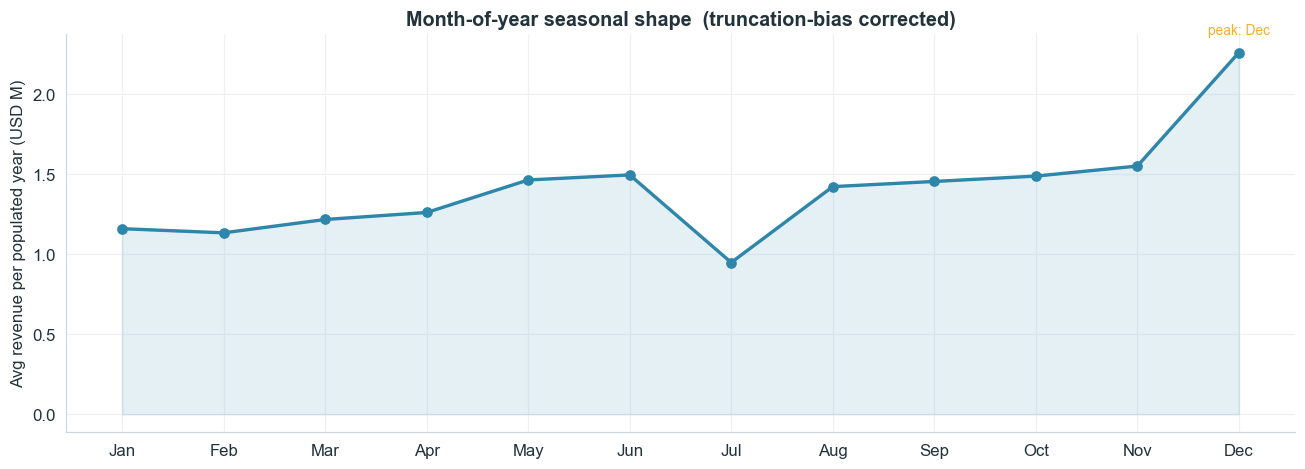

In [18]:
# average monthly revenue per *populated* year -> unbiased seasonal shape
my = df.groupby(["Year","Month_Num"])["Revenue"].sum().reset_index()
season = my.groupby("Month_Num")["Revenue"].mean()
season.index = [calendar.month_abbr[m] for m in season.index]

fig, ax = plt.subplots(figsize=(12, 4.4))
ax.plot(season.index, season.values/1e6, marker="o", color=viz.ACCENT, lw=2.2)
ax.fill_between(range(len(season)), season.values/1e6, alpha=.12, color=viz.ACCENT)
ax.set_ylabel("Avg revenue per populated year (USD M)")
ax.set_title("Month-of-year seasonal shape  (truncation-bias corrected)")
peak = season.idxmax(); trough = season.idxmin()
ax.annotate(f"peak: {peak}", (list(season.index).index(peak), season.max()/1e6),
            xytext=(0,12), textcoords="offset points", ha="center", fontsize=9, color=viz.ACCENT_2)
plt.tight_layout()
save_fig(fig, "09_seasonality")
plt.show()

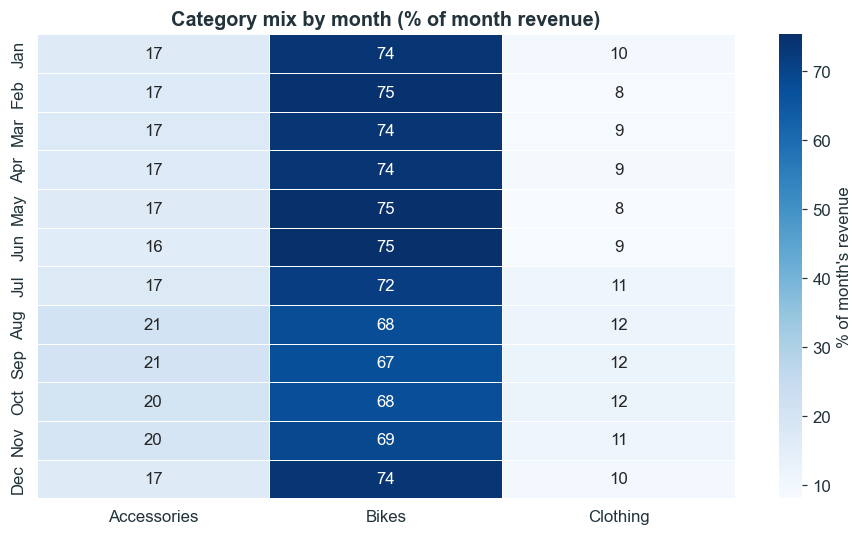

In [19]:
# month x category heatmap (share within month, robust to volume differences)
mc = (df.groupby(["Month_Num","Product_Category"], observed=True)["Revenue"].sum().unstack())
mc.index = [calendar.month_abbr[m] for m in mc.index]
mc_share = mc.div(mc.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
sns.heatmap(mc_share, annot=True, fmt=".0f", cmap="Blues",
            cbar_kws={"label": "% of month's revenue"}, ax=ax, linewidths=.5, linecolor="white")
ax.set_title("Category mix by month (% of month revenue)")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
save_fig(fig, "10_seasonality_category")
plt.show()


---
## 8 · Synthesis & recommendations

**1 · Treat Accessories as a margin business, not an afterthought.**
Accessories deliver a ~59% margin versus ~33% on Bikes. Because Accessories ride on the same customer visit as a bike purchase, the highest-ROI lever is **attach-rate**: bundling helmets, tires/tubes, bottles & cages and racks at the point of bike sale. Even a few points of attach-rate compound directly into margin.

**2 · Protect the margin mix when discounting.**
Discounts cluster on the **lowest-margin Bikes** (Section 6). Introduce **floor margins** on big-ticket bikes and redirect promotional budget toward high-margin Accessories, where a discount still leaves healthy margin and can *drive* the attach.

**3 · Concentrate commercial effort, but mind the geographic margin gap.**
Profit is concentrated: ~38% of products generate 80% of profit, and the United States + Australia alone account for ~58% of revenue. But the big markets are the *lower-margin* ones — Australia books a 31.8% margin versus 46.8% in Canada and 41.5% in the UK. Defend volume in the US/Australia while deliberately growing the **higher-margin Canada/UK** business (likely a richer accessories/clothing mix) rather than chasing volume everywhere equally.

**4 · Plan inventory to the seasonal shape, not to fake YoY growth.**
Use the truncation-corrected month-of-year curve for staffing and stock planning; do **not** extrapolate the dataset's apparent annual growth — it is a templating artifact.

---
## 9 · Limitations & data caveats

- **No customer / order id** → no RFM, CLV, retention, cohort or market-basket analysis. All demographics are transaction-level.
- **Templated, partially-truncated calendar** → no year-over-year trend claims; time is analysed only as a pooled seasonal shape.
- **1,000 injected duplicate rows removed**; 58 genuine loss-making orders retained.
- `Unit_Price` is a **list price**; realised price = `Revenue / Quantity`. The "discount" is the modelled gap between them, not a recorded promotion code.
- Dataset is a **synthetic / educational** extract (AdventureWorks lineage); findings demonstrate analytical method and are not real trading results.

*All figures in this notebook are computed from `src/data_prep.py`, guaranteeing they match the Streamlit app and README exactly.*
